In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

Lade Daten und Modell...
Pipeline erfolgreich entpackt.
SHAP Analyse läuft für 500 Samples...
Erstelle Plots...


<Figure size 1000x800 with 0 Axes>

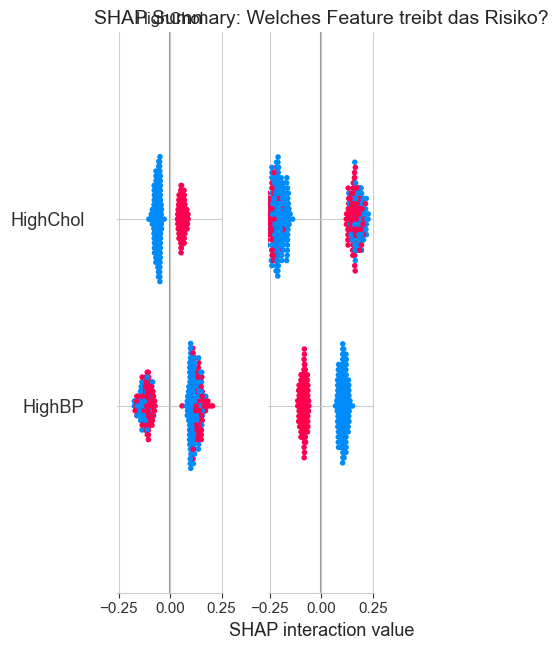

<Figure size 1000x800 with 0 Axes>

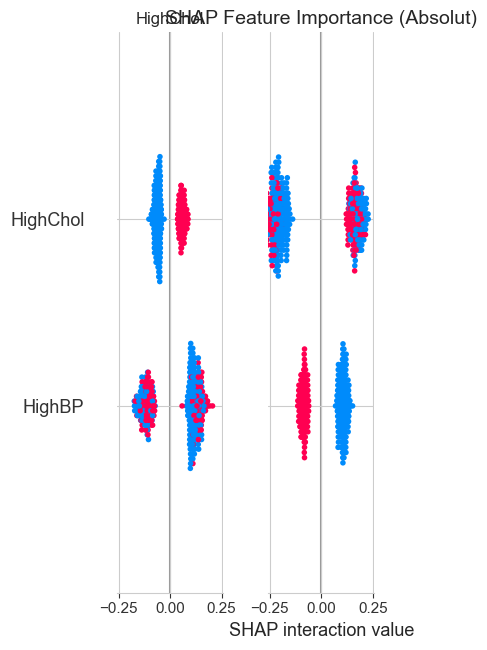


--- Analyse für Hochrisiko-Patient (Index 153) ---
Vorhergesagtes Risiko: 92.65%
Warum? (Top Einflussfaktoren):
DEBUG: Base Value: 0.5001
DEBUG: SHAP Values Shape: (16,)
DEBUG: Data Shape: (16,)


<Figure size 2000x300 with 0 Axes>

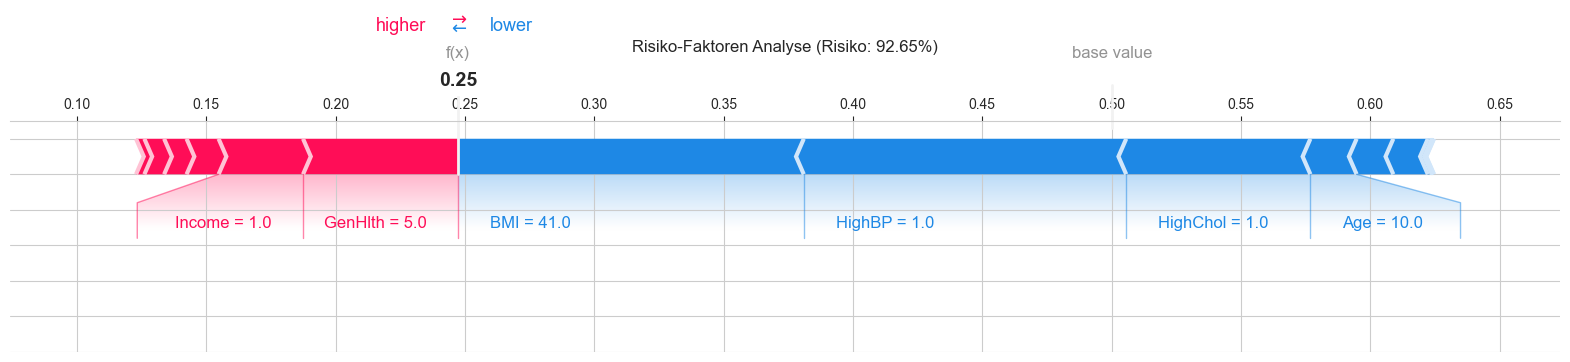


Analyse abgeschlossen. Ergebnisse in '../ml/results' gespeichert.
Explainer erfolgreich für Teil 4 gespeichert!


In [2]:
#Ziel: Modell erklärbar machen mit SHAP

# Einstellungen
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

MODEL_DIR = '../ml/model'
DATA_PATH = '../data/diabetes_binary_health_indicators_BRFSS2015.csv'
FEATURES_PATH = os.path.join(MODEL_DIR, 'selected_features.json')
RESULTS_DIR = '../ml/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1 Modell und Daten laden
print("Lade Daten und Modell...")

# Daten laden
df = pd.read_csv(DATA_PATH)
with open(FEATURES_PATH, 'r') as f:
    selected_features = json.load(f)

X = df[selected_features]
y = df['Diabetes_binary']

# Pipeline laden aus Teil 2
pipeline_path = os.path.join(MODEL_DIR, 'diabetes_pipeline.pkl')
if not os.path.exists(pipeline_path):
    print("Fehler: Modell nicht gefunden. Bitte Teil 2 ausführen.")
    exit()

full_pipeline = joblib.load(pipeline_path)

# 2 Pipeline entpacken

# Scaler holen
scaler = full_pipeline.named_steps['scaler']
# Modell holen
rf_model = full_pipeline.named_steps['clf']

print("Pipeline erfolgreich entpackt.")

# 3 Shap Vorbereitung

X_sample = X.sample(n=500, random_state=42)
X_sample_scaled = pd.DataFrame(scaler.transform(X_sample), columns=X_sample.columns)
print(f"SHAP Analyse läuft für {len(X_sample)} Samples...")

# TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample_scaled)

# Binary Classification
if isinstance(shap_values, list):
    shap_values_target = shap_values[1]
else:
    shap_values_target = shap_values

# 4 Visualisierung

print("Erstelle Plots...")

# Summary Plot (Beeswarm)
# Zeigt Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_target, X_sample_scaled, show=False, feature_names=selected_features)
plt.title('SHAP Summary: Welches Feature treibt das Risiko?', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_summary_beeswarm.png'), dpi=300)
plt.show()

# Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_target, X_sample_scaled, plot_type="bar", show=False, feature_names=selected_features)
plt.title('SHAP Feature Importance (Absolut)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_importance_bar.png'), dpi=300)
plt.show()

# 5 Erklärung

# Wahrscheinlichkeiten vorhersagen
probs = rf_model.predict_proba(X_sample_scaled)[:, 1]
max_risk_idx = np.argmax(probs)

print(f"\n--- Analyse für Hochrisiko-Patient (Index {max_risk_idx}) ---")
print(f"Vorhergesagtes Risiko: {probs[max_risk_idx]:.2%}")
print("Warum? (Top Einflussfaktoren):")

# Waterfall Plot für einen Patienten

# 1. Sicherstellen, dass der Wert skalar ist
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

# 2. SHAP-Werte zu 1D Array
if shap_values_target.ndim == 3: # Falls (1, 16, 2)
    sv = shap_values_target[0, :, 1].flatten()
elif shap_values_target.ndim == 2: # Falls (16, 2)
    sv = shap_values_target[:, 1].flatten()
else:
    sv = shap_values_target.flatten()

# 3. Patientendaten als Numpy-Array
patient_data = X_sample.iloc[max_risk_idx].values.flatten()

print(f"DEBUG: Base Value: {base_val:.4f}")
print(f"DEBUG: SHAP Values Shape: {sv.shape}") # Muss (16,) sein
print(f"DEBUG: Data Shape: {patient_data.shape}") # Muss (16,) sein

# 4. Plot-Aufruf mit expliziten Arrays
plt.figure(figsize=(20, 3))
shap.force_plot(
    base_val, 
    sv, 
    patient_data,
    feature_names=selected_features,
    matplotlib=True,
    show=False
)

plt.title(f'Risiko-Faktoren Analyse (Risiko: {probs[max_risk_idx]:.2%})', pad=50)
plt.savefig(os.path.join(RESULTS_DIR, 'shap_single_patient.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nAnalyse abgeschlossen. Ergebnisse in '../ml/results' gespeichert.")
joblib.dump(explainer, '../ml/model/shap_explainer.pkl')
print("Explainer erfolgreich für Teil 4 gespeichert!")